# ONS UK Mergers & Acquisitions — Data Quality & Governance Audit

**Author:** Mahathi Bala Satyawada

**Date:** June 2026 

**Dataset:** [ONS M&A UK Time Series](https://www.ons.gov.uk/businessindustryandtrade/changestobusiness/mergersandacquisitions/datasets/mergersandacquisitionsuk)

---

## Project Overview

The ONS UK Mergers & Acquisitions time series dataset is audited in this notebook using five data governance dimensions: **Completeness, Consistency, Timeliness, Temporal Continuity, and Schema Quality.**

In order to determine whether this dataset is appropriate for usage in an automated or machine-learning pipeline, it culminates with a scored governance scorecard and an AI readiness assessment.

**Tools:** Python, Pandas, Matplotlib

In [2]:
import pandas as pd
import numpy as np

# Load the data
df = pd.read_csv('/kaggle/input/datasets/mahathisatyawada/ons-ma-uk/am.csv')
print(df.shape)

(292, 118)


## 1. Data Loading & Structure

**Source:** Office for National Statistics (ONS) — Mergers & Acquisitions 
involving UK companies time series  
**File:** am.csv  
**Downloaded:** June 2026  

The dataset contains quarterly and annual M&A statistics for UK companies 
from 1969 to 2026 Q1, covering domestic, inward, and outward transactions 
broken down by region (EU, USA, Europe, Americas, Asia, Africa, Oceania).

In [3]:
# Inspect the raw top rows
df.head(10)

,Title,M&A : Domestic : Number of companies acquired,M&A : Domestic : Value of ordinary shares : £m,M&A : Domestic : Value of preference & loan stock : £m,M&A : Outward : Number of acquisitions,M&A : Outward : Number of disposals,M&A : Inward : Number of acquisitions,M&A : Inward : Number of disposals,M&A : Outward : Number of acquisitions in EU : Annual,M&A : Outward : Value of acquisitions in EU : Annual : £m,...,Africa Inward Acquisitions Number,Africa Inward Acquisitions Value :£m,Africa Inward Disposals Number,Africa Inward Disposals Value :£m,Africa Outward Acquisitions Number,Africa Outward Acquisitions Value :£m,Africa Outward Disposals Number,Africa Outward Disposals Value :£m,M&A : Domestic : M&A of independents : Total payments : £m,M&A : Domestic : Sales of subsidiaries between groups : Total payments : £m
0,CDID,AIHA,AIHD,AIHE,CBAQ,CBAS,CBAU,CBAW,CBAY,CBAZ,...,HCO7,HCO8,HCO9,HCP2,HCP3,HCP4,HCP5,HCP6,HIKB,HIKC
1,PreUnit,NaN,£,£,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,£,£
2,Unit,NaN,m,m,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,m,m
3,Release Date,02-06-2026,02-06-2026,02-06-2026,02-06-2026,02-06-2026,02-06-2026,02-06-2026,02-06-2026,02-06-2026,...,02-06-2026,02-06-2026,02-06-2026,02-06-2026,02-06-2026,02-06-2026,02-06-2026,02-06-2026,02-06-2026,02-06-2026
4,Next release,1 September 2026,1 September 2026,1 September 2026,1 September 2026,1 September 2026,1 September 2026,1 September 2026,1 September 2026,1 September 2026,...,1 September 2026,1 September 2026,1 September 2026,1 September 2026,1 September 2026,1 September 2026,1 September 2026,1 September 2026,1 September 2026,1 September 2026
5,Important Notes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,1969,846,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,1970,793,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,1971,884,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,1972,1210,1459,580,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Raw structure observations

Before the actual time series starts, the raw CSV has a number of non-data rows at the top:

| Row label | Purpose |
|---|---|
| `CDID` | ONS internal series identifier codes |
| `PreUnit` | Currency unit prefix (e.g. £) |
| `Unit` | Unit scale (e.g. m = millions) |
| `Release Date` | Date this edition was published |
| `Next release` | Scheduled next update |
| `Important Notes` | Methodology notes (empty in this edition) |

Prior to any analysis, these rows must be eliminated. The real data spans from row index 6 (`1969`) to `2026 Q1`.

The `Title` column mixes two granularities:
- **Annual rows** (e.g. `1969`, `1970`) — 57 rows
- **Quarterly rows** (e.g. `1987 Q1`, `2024 Q3`) — 229 rows

In [4]:
# Delete metadata
metadata_rows = ['CDID', 'PreUnit', 'Unit', 'Release Date', 'Next release', 'Important Notes']
df = df[~df['Title'].isin(metadata_rows)].copy()

# Reset index
df = df.reset_index(drop=True)
print(df.shape)
df.head()

(286, 118)


,Title,M&A : Domestic : Number of companies acquired,M&A : Domestic : Value of ordinary shares : £m,M&A : Domestic : Value of preference & loan stock : £m,M&A : Outward : Number of acquisitions,M&A : Outward : Number of disposals,M&A : Inward : Number of acquisitions,M&A : Inward : Number of disposals,M&A : Outward : Number of acquisitions in EU : Annual,M&A : Outward : Value of acquisitions in EU : Annual : £m,...,Africa Inward Acquisitions Number,Africa Inward Acquisitions Value :£m,Africa Inward Disposals Number,Africa Inward Disposals Value :£m,Africa Outward Acquisitions Number,Africa Outward Acquisitions Value :£m,Africa Outward Disposals Number,Africa Outward Disposals Value :£m,M&A : Domestic : M&A of independents : Total payments : £m,M&A : Domestic : Sales of subsidiaries between groups : Total payments : £m
0,1969,846,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1970,793,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1971,884,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1972,1210,1459,580,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1973,1205,466,147,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
# Split into annual and quarterly rows
quarterly_mask = df['Title'].str.contains(r'Q[1-4]', na=False)

df_quarterly = df[quarterly_mask].copy()
df_annual = df[~quarterly_mask].copy()

print("Quarterly rows:", df_quarterly.shape)
print("Annual rows:", df_annual.shape)

Quarterly rows: (229, 118)
Annual rows: (57, 118)


In [6]:
# Replace empty strings with NaN; Quarterly rows
df_quarterly = df_quarterly.replace('', np.nan)

df_quarterly.info()

<class 'pandas.core.frame.DataFrame'>
Index: 229 entries, 57 to 285
Columns: 118 entries, Title to M&A : Domestic : Sales of subsidiaries between groups : Total payments : £m
dtypes: object(118)
memory usage: 212.9+ KB


In [7]:
# Convert numeric-looking columns
key_cols = [
    "M&A : Domestic : Number of companies acquired",
    "M&A : Domestic : M&A of independents : number acquired",
    "M&A : Domestic : Sales of subsidiaries between groups : number acquired"
]

for c in key_cols:
    df_quarterly[c] = pd.to_numeric(df_quarterly[c], errors="coerce")

df_quarterly[key_cols].head()

,M&A : Domestic : Number of companies acquired,M&A : Domestic : M&A of independents : number acquired,M&A : Domestic : Sales of subsidiaries between groups : number acquired
57,235,NaN,NaN
58,236,NaN,NaN
59,187,NaN,NaN
60,188,NaN,NaN
61,206,NaN,NaN


In [8]:
# Keep only quarterly-relevant columns
quarterly_cols = [
    c for c in df_quarterly.columns
    if c!='Title' and 'Annual' not in c
]

df_q_core = df_quarterly[quarterly_cols].copy()

In [9]:
# Percentage of missing values per column for quarterly rows
missing_pct_core = (df_q_core.isna().sum() / len(df_q_core) * 100).sort_values(ascending=False)

print("=== Completeness summary (quarterly rows) ===")
print(f"Columns with 0% missing : {(missing_pct_core == 0).sum()}")
print(f"Columns with 1-50% missing : {((missing_pct_core > 0) & (missing_pct_core <= 50)).sum()}")
print(f"Columns with >50% missing : {(missing_pct_core>50).sum()}")
print(f"Columns with 100% missing : {(missing_pct_core == 100).sum()}")

print("\nTop 10 most incomplete columns ")
missing_pct_core.head(10)

=== Completeness summary (quarterly rows) ===
Columns with 0% missing : 2
Columns with 1-50% missing : 19
Columns with >50% missing : 56
Columns with 100% missing : 56

Top 10 most incomplete columns 


Other Europe Outward Acquisitions Value :£m    100.0
Other Europe Outward Disposals Number          100.0
Other Europe Outward Disposals Value :£m       100.0
Other Europe Inward Acquisitions Value :£m     100.0
Other Europe Inward Acquisitions Number        100.0
Europe Total Inward Disposals Number           100.0
Europe Total Inward Disposals Value: £m        100.0
Europe Total Outward Acquisitions Number       100.0
Europe Total Outward Acquisitions Value :£m    100.0
Europe Total Outward Disposals Number          100.0
dtype: float64

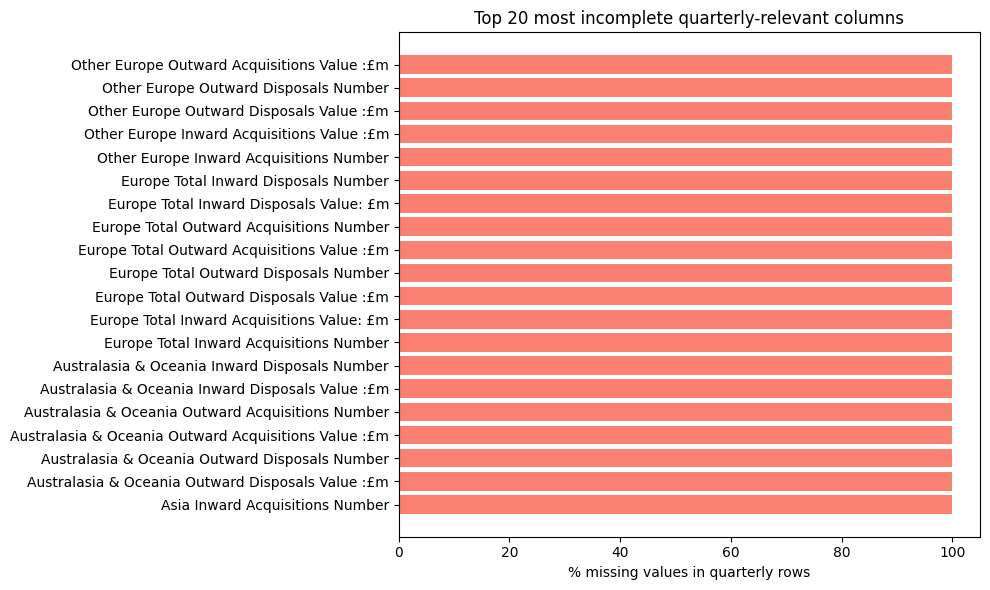

In [10]:
#Bar chart of the worst columns
import matplotlib.pyplot as plt

top20 = missing_pct_core[missing_pct_core > 0].head(20)

plt.figure(figsize=(10, 6))
plt.barh(top20.index[::-1], top20.values[::-1], color="salmon")
plt.xlabel("% missing values in quarterly rows")
plt.title("Top 20 most incomplete quarterly-relevant columns")
plt.tight_layout()
plt.show()

### Completeness finding

The quarterly dataset still includes a number of region-level inward and outward acquisition/disposal series with extremely significant missingness even after clearly annual-only fields are removed. This indicates that the file combines a larger variety of sporadically populated regional indicators with a small collection of core quarterly series that are regularly populated.

In [11]:
# Schema / header quality checks
cols = pd.Series(df.columns)

typos = cols[cols.str.contains("Ouward", na=False)]
print("Columns with typo 'Ouward'")
print(typos.tolist())

money_cols = cols[cols.str.contains("£m", na=False)]
print("\nSample money columns:")
print(money_cols.head(20).tolist())


Columns with typo 'Ouward'
['Asia Ouward Disposals Value :£m']

Sample money columns:
['M&A : Domestic : Value of ordinary shares : £m', 'M&A : Domestic : Value of preference & loan stock : £m', 'M&A : Outward : Value of acquisitions in EU : Annual : £m', 'M&A : Outward : Value of acquisitions in USA : Annual : £m', 'M&A : Outward : Value of acquisitions : £m', 'M&A : Outward : Value of disposals in EU : Annual : £m', 'M&A : Outward : Value of disposals in USA : Annual : £m', 'M&A : Outward : Value of disposals : £m', 'M&A : Outward : Value of acquisitions - direct transactions : Annual : £m', 'M&A : Outward : Value of acquisitions - indirect funded in UK : Annual : £m', 'M&A : Outward : Value of acquisitions - indirect funded locally : Annual : £m', 'M&A : Outward : Value of disposals - direct transactions : Annual : £m', 'M&A : Outward : Value of disposals - indirect funded in UK : Annual : £m', 'M&A : Outward : Value of disposals - indirect funded locally : Annual : £m', 'M&A : Inwa

In [12]:
# Count header formatting variants
print("Contains ' :£m' :", cols.str.contains(" :£m", regex=False).sum())
print("Contains ': £m' :", cols.str.contains(": £m", regex=False).sum())
print("Contains ' : £m':", cols.str.contains(" : £m", regex=False).sum())

Contains ' :£m' : 26
Contains ': £m' : 33
Contains ' : £m': 31


### Schema / header quality

- Found 1 clear typo in a column name: `Asia Ouward Disposals Value :£m`
  (missing the **t** in "Outward").
- Detected inconsistent header formatting for monetary fields:
  - 26 columns use `" :£m"`
  - 33 columns use `": £m"`
  - 31 columns use `" : £m"`

The possibility of faulty column-name matching in downstream code or metadata tools is increased by this discrepancy. These patterns would be standardized at ingestion time via a pipeline that complies with governance.

In [13]:
# Internal consistency check
total_col = "M&A : Domestic : Number of companies acquired"
ind_col   = "M&A : Domestic : M&A of independents : number acquired"
subs_col  = "M&A : Domestic : Sales of subsidiaries between groups : number acquired"

cons = df_quarterly[[total_col, ind_col, subs_col]].copy()
for c in [total_col, ind_col, subs_col]:
    cons[c] = pd.to_numeric(cons[c], errors="coerce")

cons["calculated_total"] = cons[ind_col] + cons[subs_col]
cons["difference"] = cons[total_col] - cons["calculated_total"]

mismatches = cons[cons["difference"].abs() > 2].dropna()
print("Rows checked :", cons.dropna().shape[0])
print("Mismatches > 2 :", len(mismatches))
mismatches.head()

Rows checked : 213
Mismatches > 2 : 56


,M&A : Domestic : Number of companies acquired,M&A : Domestic : M&A of independents : number acquired,M&A : Domestic : Sales of subsidiaries between groups : number acquired,calculated_total,difference
69,278,0.0,0.0,0.0,278.0
70,326,0.0,0.0,0.0,326.0
71,285,0.0,0.0,0.0,285.0
72,321,938.0,272.0,1210.0,-889.0
73,362,0.0,0.0,0.0,362.0


### Why internal consistency matters for governance

Downstream systems frequently rely on the presumption that component series add up to their reported totals when a dataset is used in an automated pipeline.
A mismatch indicates one of two things:
- In certain times (before to 1987), the component series were not reported.
- Reporting definitions evolved over time, or
- The components and total are obtained from several survey tools.

This relationship should be verified before being used by any AI/ML pipeline that consumes these fields.

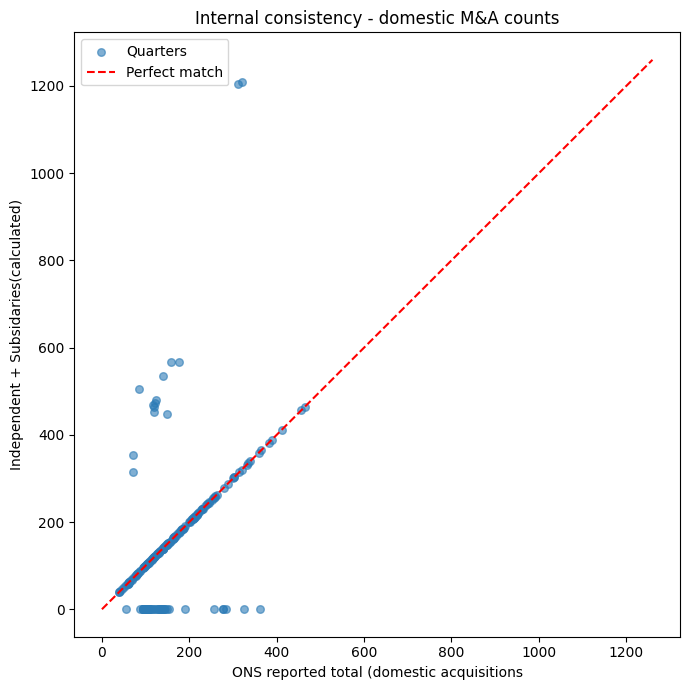

In [14]:
#reported total vs calculated total
plot_df = cons.dropna().copy()

plt.figure(figsize=(7, 7))
plt.scatter(
    plot_df[total_col],
    plot_df["calculated_total"],
    alpha=0.6,
    s=30,
    color="#2c7bb6",
    label="Quarters"
)

lims = [
    0,
    max(plot_df[total_col].max(), plot_df["calculated_total"].max()) + 50
]

plt.plot(lims, lims, "r--", linewidth=1.5, label="Perfect match")
plt.xlabel("ONS reported total (domestic acquisitions")
plt.ylabel("Independent + Subsidaries(calculated)")
plt.title("Internal consistency - domestic M&A counts")
plt.legend()
plt.tight_layout()
plt.show()

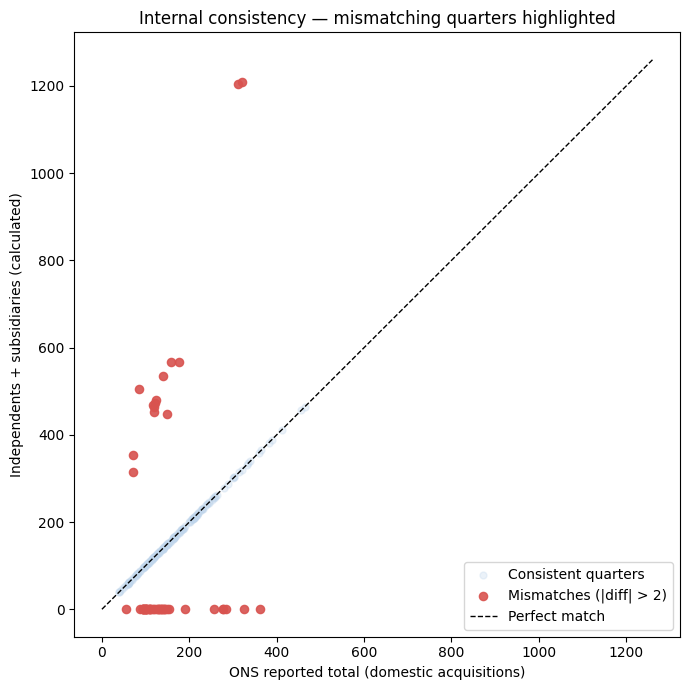

In [15]:
# Overlay mismatches
bad = cons[(cons["difference"].abs() > 2) & cons["difference"].notna()]

plt.figure(figsize=(7, 7))
plt.scatter(
    plot_df[total_col],
    plot_df["calculated_total"],
    alpha=0.3,
    s=25,
    color="#c0d6ec",
    label="Consistent quarters"
)
plt.scatter(
    bad[total_col],
    bad["calculated_total"],
    alpha=0.9,
    s=35,
    color="#d9534f",
    label="Mismatches (|diff| > 2)"
)
plt.plot(lims, lims, "k--", linewidth=1, label="Perfect match")
plt.xlabel("ONS reported total (domestic acquisitions)")
plt.ylabel("Independents + subsidiaries (calculated)")
plt.title("Internal consistency — mismatching quarters highlighted")
plt.legend()
plt.tight_layout()
plt.show()

### Internal consistency finding
The reported total number of companies bought and the total of two component series—acquisitions of independent companies and sales of subsidiaries across groups—were compared in the domestic M&A consistency check.

There is general agreement between the stated total and the rebuilt total, as evidenced by the majority of quarters lying near the 45-degree reference line. Nevertheless, 56 of the 213 examined quarters—including a number of significant outliers—show a difference larger than 2. This implies that reporting definitions varied across the series or that the component series are not entirely additive in all eras.

From a governance standpoint, it is not appropriate to presume that these fields would precisely reconcile without first reviewing methodological notes or metadata.

In [16]:
#checking time continuity

df_quarterly["year"]    = df_quarterly["Title"].str.extract(r"(\d{4})").astype(int)
df_quarterly["quarter"] = df_quarterly["Title"].str.extract(r"Q(\d)").astype(int)

df_quarterly["period"] = pd.PeriodIndex.from_fields(
    year=df_quarterly["year"],
    quarter=df_quarterly["quarter"],
    freq="Q"
)

df_quarterly[["Title", "year", "quarter", "period"]].head()

full_range = pd.period_range(
    start=df_quarterly["period"].min(),
    end=df_quarterly["period"].max(),
    freq="Q"
)

actual_periods = set(df_quarterly["period"])
missing_quarters = [p for p in full_range if p not in actual_periods]

print("Expected quarters:", len(full_range))
print("Actual quarters  :", len(df_quarterly))
print("Missing quarters :", len(missing_quarters))
if missing_quarters:
    print(missing_quarters)

Expected quarters: 229
Actual quarters  : 229
Missing quarters : 0


### Temporal continuity finding

There are no missing quarters in the quarterly time series from 1969 Q1 to 2026 Q1 (229 expected, 229 found). The dataset's structural completeness and suitability for uninterrupted time-series analysis on the primary quarterly series constitute a substantial governance advantage.

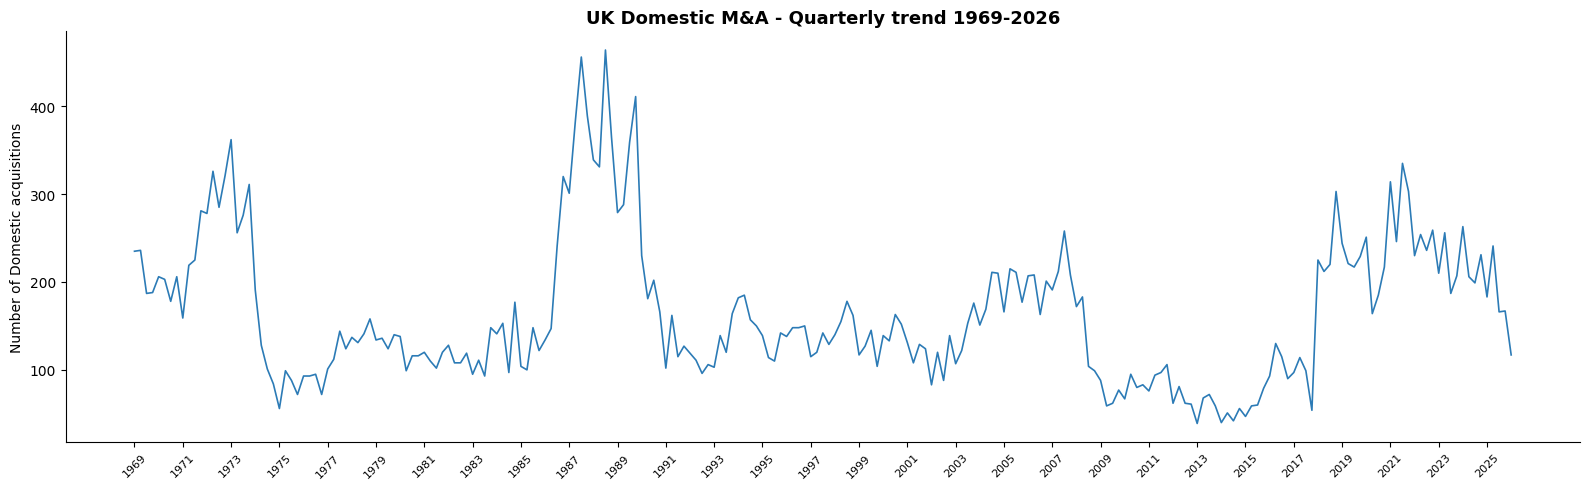

In [21]:
#main trend plot
import matplotlib.patches as mpatches

plot = df_quarterly[["period", total_col]].copy()
plot[total_col] = pd.to_numeric(plot[total_col], errors="coerce")
plot = plot.dropna()

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(plot.index, plot[total_col], color="#2c7bb6", linewidth=1.2)

events = {
    "2008-2009\nFinancial Crisis" : ("2008 Q1", "2009 Q4", "#d9534f"),
    "2016\nBrexit Vote":         ("2016 Q1", "2016 Q4", "#f0ad4e"),
    "2020\nCOVID-19":            ("2020 Q1", "2020 Q4", "#9b59b6"),
}

for label, (start, end, color) in events.items():
    s = plot[plot["period"].astype(str) == start].index
    e = plot[plot["period"].astype(str) == end].index
    if len(s) and len(e):
        ax.axvspan(s[0], e[0], alpha=0.15, color=color, label=label)
        ax.text(s[0], plot[total_col].max() * 0.95,
                label, fontsize=7.5, color=color,
                rotation=90, va="top")

ax.set_ylabel("Number of Domestic acquisitions")
ax.set_title("UK Domestic M&A - Quarterly trend 1969-2026", fontsize=13, fontweight="bold")

# Clean x-axis: show a year label every 4th quarter
tick_pos = plot.index[::8]
tick_labels = [str(plot["period"].iloc[i])[:4] for i in range(0, len(plot), 8)]
ax.set_xticks(tick_pos)
ax.set_xticklabels(tick_labels, rotation=45, fontsize=8)
ax.spines[["top", "right"]].set_visible(False)
plt.savefig("ma_trend.png", dpi=150, bbox_inches="tight")
plt.tight_layout()
plt.show()


---
## Summary of Findings

| # | Finding | Dimension | Severity |
|---|---|---|---|
| 1 | Regional sub-series are ~100% missing in quarterly rows | Completeness | Medium |
| 2 | 56/213 quarters show inconsistency between total and components | Consistency | Medium |
| 3 | 1 column name typo: `Asia Ouward Disposals Value` | Schema Quality | Low |
| 4 | 3 inconsistent £m header formats across 90 columns | Schema Quality | Low |
| 5 | Quarterly backbone complete: 229/229 quarters present | Temporal Continuity | ✅ Positive |
| 6 | Updated to 2026 Q1; next release September 2026 | Timeliness | ✅ Positive |

---

In [22]:
#Governance Scorecard
scorecard = pd.DataFrame({
    "Dimension": [
        "Completeness",
        "Consistency",
        "Timeliness",
        "Temporal Continuity",
        "Schema Quality"
    ],
    "Score (1-5)": [3, 3, 5, 5, 3],
    "Evidence": [
        "In quarterly rows, regional series (Europe, Asia, Oceania, Americas) are almost entirely absent; they are structurally minimalist by design but lack documentation",
        "There is a difference between the reported total and the sum of the component series (independents + subsidiaries) in 56 out of 213 quarterly rows (26%).",
        "As of June 2026, it was updated to 2026 Q1; the next release is set for September 2026; the usual quarterly cadence is maintained throughout.",
        "The backbone is structurally complete after 229 continuous quarters from 1969 Q1 to 2026 Q1 with no gaps.",
        "Three inconsistent £m header formats (':£m', ': £m', ': £m') across ninety columns; one column name typo ('Ouward' instead of 'Outward')"
    ],
    "Recommendation": [
        "Clearly record annual-only columns in a data dictionary and mark them as inappropriate for quarterly AI/ML application without aggregation.",
        "Do not assume additivity over the entire history; instead, look at methodology notes for the pre-1987 period where component series seem unreported.",
        "Timeliness is robust, thus no intervention is required.",
        "The temporal backbone is complete, so no intervention is required.",
        "Correct typos in downstream pipelines and standardize column nomenclature during ingestion."
    ]
})

scorecard.to_csv("governance_scorecard.csv", index=False)
print("Saved: governance_scorecard.csv")
scorecard

Saved: governance_scorecard.csv


,Dimension,Score (1-5),Evidence,Recommendation
0,Completeness,3,"In quarterly rows, regional series (Europe, As...",Clearly record annual-only columns in a data d...
1,Consistency,3,There is a difference between the reported tot...,Do not assume additivity over the entire histo...
2,Timeliness,5,"As of June 2026, it was updated to 2026 Q1; th...","Timeliness is robust, thus no intervention is ..."
3,Temporal Continuity,5,The backbone is structurally complete after 22...,"The temporal backbone is complete, so no inter..."
4,Schema Quality,3,"Three inconsistent £m header formats (':£m', '...",Correct typos in downstream pipelines and stan...


### Overall verdict

| Dimension | Score |
|---|---|
| Completeness | 3/5 |
| Consistency | 3/5 |
| Timeliness | 5/5 |
| Temporal Continuity | 5/5 |
| Schema Quality | 3/5 |

**Overall: 3.8 out of 5— Suitable for descriptive analytics on the primary domestic data and quarterly trend analysis. Before being used in any automated or AI-driven workflow, regional sub-series and component breakdowns must be carefully validated.**

## AI Readiness Assessment

Would an AI or ML pipeline be able to use this dataset as input?
We assess it using five standards for ethical AI data governance.

In [23]:
#AI Readiness Assessment
ai_assessment = pd.DataFrame({
    "Criterion": [
        "Label availability",
        "Feature complteness",
        "Temporal leak risk",
        "Structural break risk",
        "Data volume",
    ],
    "Assessment": [
        "The dataset is unsupervised and lacks labels. Only appropriate for predicting or anomaly detection; not suitable for categorization without further labeling.",
        "The core quarterly series (outward/inward totals, domestic acquisitions) is finished. Regional sub-series cannot be utilized directly as quarterly features; they must first be aggregated annually.",
        "The most recent quarter is tentative and could be revised by ONS. The most recent one or two quarters should be marked as unreliable by any automated workflow that uses this data.",
        "The 2008–09 financial crisis, the 2016 Brexit referendum, and the 2020 COVID-19 pandemic were found to be three significant structural breaches. Without windowing, a model trained over the whole period would pick up knowledge from essentially distinct market regimes.",
        "For traditional time-series models (ARIMA, Prophet, Exponential Smoothing), 229 quarterly rows are adequate. Insufficient without augmentation for deep learning."
    ],
    "AI ready?": ["Partial", "Partial", "⚠ Flag", "⚠ Flag", "✓ Yes"]
})

ai_assessment

,Criterion,Assessment,AI ready?
0,Label availability,The dataset is unsupervised and lacks labels. ...,Partial
1,Feature complteness,The core quarterly series (outward/inward tota...,Partial
2,Temporal leak risk,The most recent quarter is tentative and could...,⚠ Flag
3,Structural break risk,"The 2008–09 financial crisis, the 2016 Brexit ...",⚠ Flag
4,Data volume,"For traditional time-series models (ARIMA, Pro...",✓ Yes


### AI readiness verdict

**Recommended use:** Time-series forecasting and descriptive analytics are limited to the primary quarterly domestic M&A series.

**Not recommended for:** Tasks involving classification without further labeling; cross-sectional machine learning employing regional sub-series without first performing an annual aggregation.

**Governance actions before AI use:**
1. Remove from quarterly feature sets any columns marked `: Annual`.
2. To prevent cross-regime leaking, use a rolling train or test window
3. In any automatic output, mark the most recent quarter as preliminary.
4. Standardize column names to eliminate typos and inconsistent £m spacing.

---
*Dataset: ONS Mergers & Acquisitions UK Time Series | Audit by mahibala9 | June 2026*
*Source: https://www.ons.gov.uk/businessindustryandtrade/changestobusiness/mergersandacquisitions*